# Evaluating the output of the SCIP solver of CVXPY

In [1]:
from av_mat_generation.CI_based.window import Window
from datetime import datetime
import pandas as pd
import numpy as np
import cvxpy as cp
import random

MAIN_FOLDER = 'availability_matrices/av-mat-scalability'
start_time=datetime(2022, 1, 1, 0, 0)
max_rounds=90
ft=1

In [2]:
# Diff nb clients: 
nb_clients_list = [7, 14, 28, 54]
# Diff base training time T (equiv to carbon budget)
T = [90, 75, 60, 45, 30, 15, 5, 3] #train time list
# Diff s: 
s_list = [20, 40, 60, 80, 100]

[39.99505500000002 32.887908 25.744709999999998 18.710061 12.268464
 5.877915 2.021325 1.240998]
90


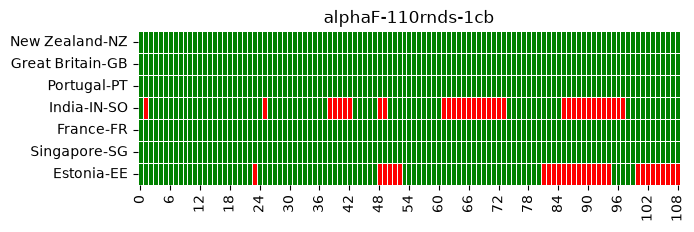

target:  39.461961000000024
result:  39.42220200000003


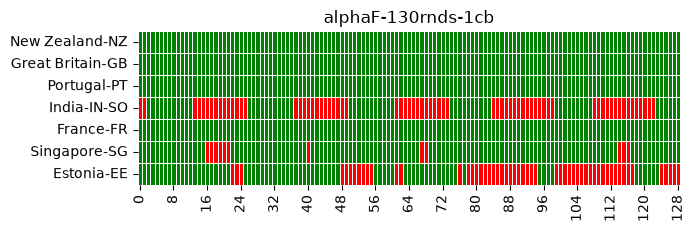

target:  39.478374000000024
result:  39.474989999999984


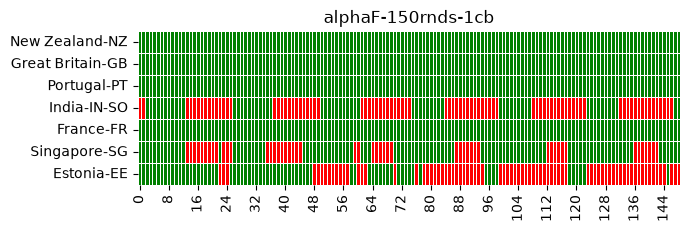

target:  39.52090800000002
result:  39.518931


c:\Users\c.q.rodriguez\Downloads\GITHUB\GreenFL\building_availability_matrices\av_mat_generation\CI_based\window.py:411: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(


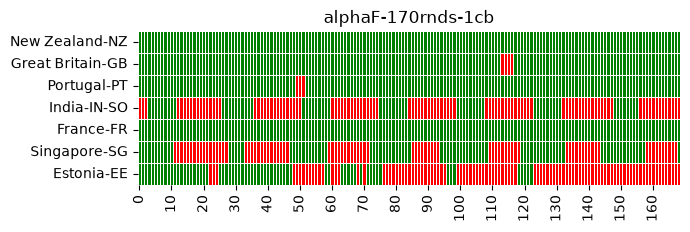

target:  39.366249000000025
result:  39.359613


c:\Users\c.q.rodriguez\Downloads\GITHUB\GreenFL\building_availability_matrices\av_mat_generation\CI_based\window.py:411: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(


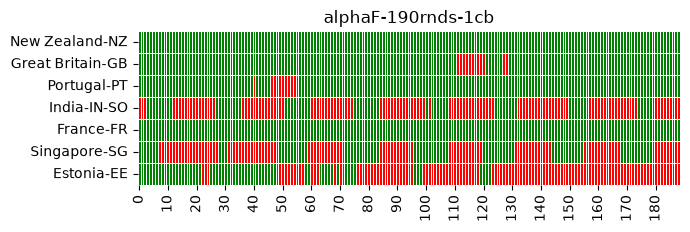

target:  39.48408900000002
result:  39.477108000000044
75


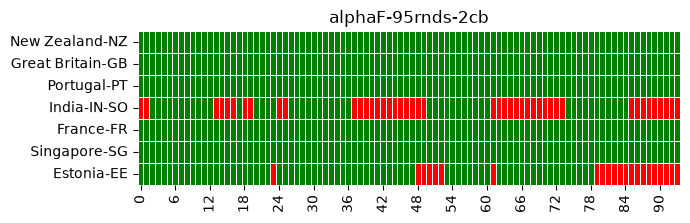

target:  32.398677000000006
result:  31.98945000000002


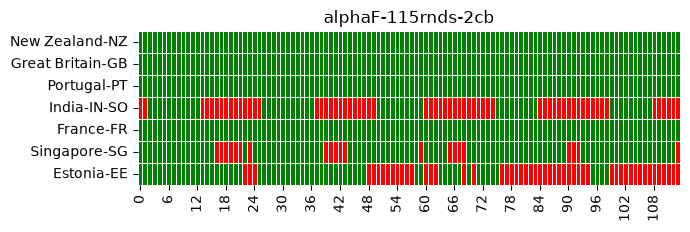

target:  32.352900000000005
result:  32.351613000000015


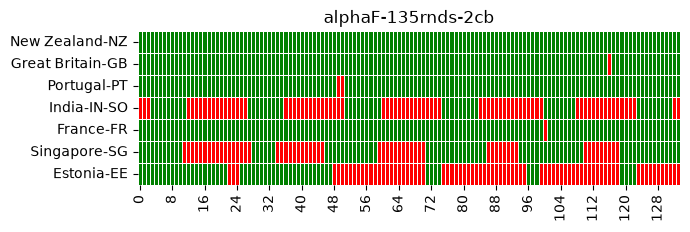

target:  32.357106
result:  32.347374


c:\Users\c.q.rodriguez\Downloads\GITHUB\GreenFL\building_availability_matrices\av_mat_generation\CI_based\window.py:411: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(


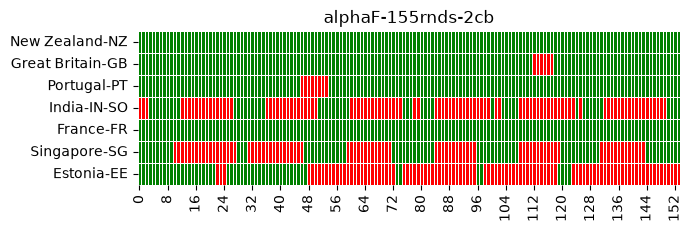

target:  32.39043
result:  32.384868000000004


c:\Users\c.q.rodriguez\Downloads\GITHUB\GreenFL\building_availability_matrices\av_mat_generation\CI_based\window.py:411: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(


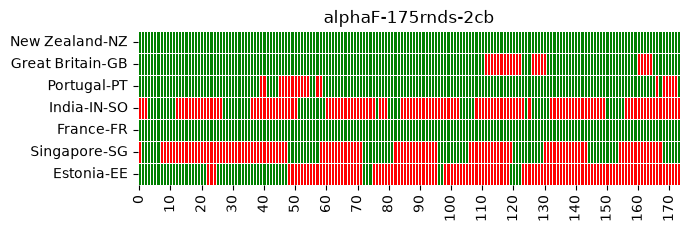

target:  32.336172000000005
result:  32.333960999999995
60


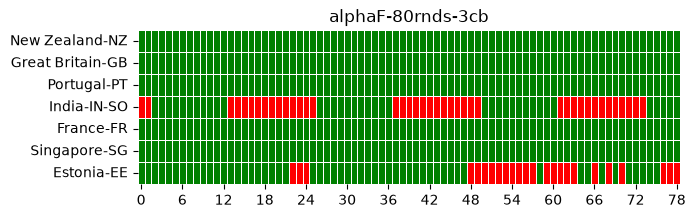

target:  25.276829999999997
result:  25.238265000000013


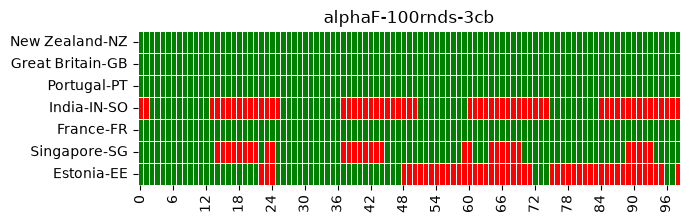

target:  25.308621
result:  25.308531


KeyboardInterrupt: 

In [3]:
for nb_clients in nb_clients_list:
    win = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=max_rounds, custom_client_list=nb_clients)
    res = win.get_GHG_matrix()
    carbon_budget_considered = res.sum().cumsum().to_numpy().take([89,74,59,44,29,14,4,2])
    print(carbon_budget_considered)
    for ii, carbon_budget in enumerate(carbon_budget_considered):
        print(T[ii])
        for s in [20,40,60,80,100]:
            win1 = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=T[ii]+s, custom_client_list=nb_clients)
            win = Window(start_time=start_time, out_folder=MAIN_FOLDER, n_rounds=T[ii]+s-ft, custom_client_list=nb_clients)
            try:
                av_mat = win.get_av_mat(method='cvxpy_scip', fine_tuning=False, carbon_budget=carbon_budget-win1.get_GHG_matrix().to_numpy()[:,-ft:].sum(), key_word=f"alphaF-{T[ii]+s}rnds-{ii+1}cb")
                availability_df = pd.DataFrame(np.hstack([av_mat.to_numpy(),np.ones((7,ft))]), index=win.countries, columns=[i for i in range(av_mat.shape[1]+ft)])
                key_word=f"alphaF-{T[ii]+s}rnds-{ii+1}cb-{ft}ft"
                dict_cols = dict(
                zip([i for i in range(win.n_rounds+ft)], win1.window_list_hours[:win.n_rounds+ft])
            )  # get the datetime values
                availability_matrix_to_save = availability_df.rename(columns=dict_cols)
                availability_matrix_to_save.to_csv(
                    win.out_folder + "/av-mat_" + key_word + ".csv",
                    columns=win1.window_list_hours[:win.n_rounds+ft],
                )
            except Exception as e:
                print(f"Failed! Exception: {e}")
                continue
        continue